## Concise: 1: Start and mesh
Author: yanjun zhang, Source from book "Abali - 2017 - Computational Reality" P119

In [1]:
from disc_f_wear import *

# mesh-size, contact area coefficient
mesh_min, mesh_max = 3, 30
c_contact          = 1

# Each time step rotation angular, and acc during lag, 1 is full acc, 0 is no acc.
angular_r          = 0.3
v_vehicle, c_acc   = 160, 1
z1,z2,z3,z4,z_all  = 20,33,30,83,8
pad_v_tag          = 32
alpha_thermal      = 1.5e-6 #thermal expansion coefficient
penalty_param      = 400
k_wear             = 6.7e-6/10
wear_f             = 'on'   # on is open for wear calcualtion on deformation
# calling local functions to get all parameters
(dt, P, g, num_steps, h, radiation, v_angular, \
 Ti, Tm, S_rub_circle_ini, t, rho, c, k, t_brake, 
S_total,)                                       = vehicle_initial (angular_r, v_vehicle, c_contact, c_acc)
print("1: Total braking tims is ", round(sum(dt), 2), "s")
print("2: Total numb steps is ", num_steps)

## here use lots of abbreviation, details are in disc_f
domain, cell_markers, facet_markers, mesh_name, mesh_name1, mesh_name2 \
                       = mesh_brake_all(mesh_min,mesh_max,pad_v_tag)

V, T_init, u_n         = initial_u_n(domain, Ti)

fdim, bc, mesh_brake, all_e,xdmf, x_co, y_co, ds, b_con \
                       = mesh_setup( domain, V, mesh_name1, num_steps, \
                         angular_r, mesh_name2, c_contact, z_all, Tm, S_rub_circle_ini)
# Initialize
problem, u, v, f, n_vector = variation_initial(V, T_init, domain, rho, c, b_con,\
                          radiation, h, k, xdmf, dt, ds, u_n, Tm,g,bc);
solver_setup_solve(problem,u)

## Visualization of time dependent problem using pyvista
gif_name    = "T-s-{}-d-{}-{}-c-{}-e-{}.gif".format(num_steps, angular_r, mesh_name2, c_contact, all_e)
plotter, sargs, renderer, warped, viridis, grid = plot_gif(V,u,gif_name)
##solve
num_steps= int(num_steps)
#num_steps= int(10)
#break
###################################################################
x_co_zone   = 0.0001

T_array,fraction_c,deformed_co,u_d1, d_wear   = solve_heat(Ti, u, num_steps, dt, x_co, y_co, angular_r, \
               t_brake, domain, S_rub_circle_ini, fdim,\
               rho, c, v, radiation, k, h, f, Tm, g,\
               ds, xdmf, b_con, bc, plotter, warped,\
               mesh_name1, mesh_brake, pad_v_tag, z4,\
               z1, x_co_zone, u_n, alpha_thermal, penalty_param, P, k_wear, wear_f)  #last u should be u_n, here we set u, \
#the same with previous:solver_setup_solve(problem,u)
####################################################################

csv_name    = "Result_T-s-{}-d-{}-{}-c-{}-e-{}.csv".format(num_steps, angular_r, mesh_name2, c_contact, all_e  )
#save_t_T(csv_name, T_array) # got the Temperature data

from IPython.display import display, Image
display(Image(gif_name))

DOLFINx version: 0.9.0
Simulation environment setup complete.


KeyboardInterrupt: 

In [ ]:
print( "The wear depeth is", sum(d_wear), "mm" )
plt.plot(d_wear)

In [ ]:
print(P)

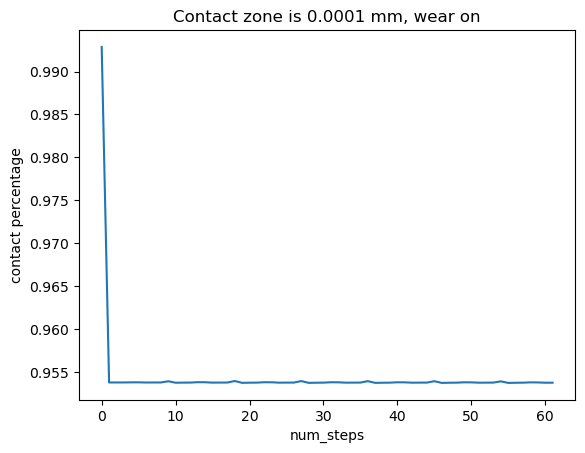

In [4]:
plt.plot(fraction_c)
plt.title (f"Contact zone is {x_co_zone} mm, wear {wear_f}")
#plt.ylim(0,1.5)
plt.xlabel("num_steps")
plt.ylabel("contact percentage")
plt.savefig("new_figure.png")

In [5]:
print(fraction_c)

[0.9928705843334424, 0.9537650379009208, 0.9537650379088857, 0.9537650379090205, 0.9537774895756218, 0.9537790512540865, 0.9537606909514671, 0.9537623710127964, 0.9537631480578485, 0.9539068102552767, 0.9537344372455964, 0.9537473345363158, 0.953752922131513, 0.9537968455986668, 0.9537902980687073, 0.9537471208498216, 0.9537527389871147, 0.9537556280727791, 0.9539334341658494, 0.953721291874471, 0.9537385598169383, 0.9537461997549012, 0.9537906848558225, 0.9537848369475378, 0.9537429236308994, 0.9537491631897825, 0.9537524793374516, 0.953926795126526, 0.9537180689738222, 0.9537361163301417, 0.9537440894781534, 0.9537878768334012, 0.9537820139033522, 0.9537410920716897, 0.9537475975501407, 0.9537510474796511, 0.9539202966255516, 0.9537160156812757, 0.9537348064547099, 0.9537429984466026, 0.9537856083606806, 0.9537795731960267, 0.9537399134372079, 0.9537466397469487, 0.9537501516993021, 0.953911844511766, 0.9537141635604356, 0.9537338607971134, 0.9537422443071678, 0.9537828715678137, 0.9